## Gaussian-noise experiment

### Functions used in this section

| Function | Inputs | Purpose |
|---|---|---|
| `design_observer` | `A, C` | Places the observer poles and returns the observer gain and observer state matrix. |
| `compute_true_theta` | `A_o, B, C, G, n_lag` | Builds the true observer parameter vector from the observer Markov parameters. |
| `make_output_filter` | `A, B, C` | Converts the SISO state-space model to a discrete transfer-function filter. |
| `simulate_output` | `u, noise_std, filter_numerator, filter_denominator` | Simulates the output efficiently and adds measurement noise. |
| `simulate_state_space` | `A, B, C, u, noise_std=0.0` | Simulates the full state-space trajectory. |
| `generate_white_noise_input` | `N` | Generates a white Gaussian input sequence. |
| `build_regressor` | `u, y, n_lag` | Constructs the lagged ARX regressor matrix and aligned output vector. |
| `least_squares_statistics` | `Phi, Y` | Helper function used in this experiment. |
| `least_squares_inverse` | `Phi, Y` | Helper function used in this experiment. |
| `adaptive_weights_from_theta` | `theta_init, delta=1e-3, power=1.0` | Helper function used in this experiment. |
| `make_adaptive_lasso_weights` | `Phi, Y, delta=1e-3, power=1.0` | Helper function used in this experiment. |
| `psd_square_root_factor` | `Q` | Helper function used in this experiment. |
| `weighted_lasso_constrained` | `Phi, Y, epsilon, weights=None, lambda_l2=0.0, solver_cache=None, theta_ls=None, Q=None, rss_min=None,` | Solves the constrained weighted-LASSO problem. |
| `run_fair_comparison_one_noise` | `A, B, C, sample_sizes, noise_std, epsilon, num_trials, n_lag, lambda_l2, weight_delta, weight_power, G=None, A_o=None, theta_true=None, progress_every=25,` | Helper function used in this experiment. |
| `run_all_experiments` | `` | Helper function used in this experiment. |
| `plot_all_results` | `all_results, error_threshold=None,` | Helper function used in this experiment. |
| `plot_boxplot_results` | `all_results, N_box=None, error_threshold=None,` | Helper function used in this experiment. |
| `save_figure` | `fig, fig_dir=None, basename=None, axis_width=r"\linewidth", axis_height=r"0.58\linewidth",` | Helper function used in this experiment. |


In [7]:
from pathlib import Path
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from scipy.signal import lfilter, place_poles, ss2tf
import matplotlib.pyplot as plt
import cvxpy as cp

def design_observer(A, C):
    desired_poles = np.array([1e-8, 2e-15])
    place_obj = place_poles(A.T, C.T, desired_poles)

    G = place_obj.gain_matrix.T
    A_o = A - G @ C

    print("Desired poles:", desired_poles)
    print("Actual placed poles:", place_obj.computed_poles)
    print("Poles of A_o:", np.linalg.eigvals(A_o))

    return G, A_o


def compute_true_theta(A_o, B, C, G, n_lag):
    """Compute Markov parameters without repeated matrix_power calls."""
    theta_u = np.empty(n_lag, dtype=float)
    theta_y = np.empty(n_lag, dtype=float)

    A_power_B = np.asarray(B, dtype=float)
    A_power_G = np.asarray(G, dtype=float)

    for i in range(n_lag):
        theta_u[i] = (C @ A_power_B).item()
        theta_y[i] = (C @ A_power_G).item()
        A_power_B = A_o @ A_power_B
        A_power_G = A_o @ A_power_G

    return np.hstack((theta_u, theta_y))

def make_output_filter(A, B, C):
    """
    Convert the SISO state-space model to a discrete transfer function.

    With x[0] = 0 and D = 0, lfilter produces the same output sequence
    y[k] = C x[k] as the state recursion, up to floating-point roundoff.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)

    if B.shape[1] != 1 or C.shape[0] != 1:
        raise ValueError("The output filter currently requires a SISO system.")

    D = np.zeros((C.shape[0], B.shape[1]), dtype=float)
    numerator, denominator = ss2tf(A, B, C, D)

    return np.asarray(numerator[0], dtype=float), np.asarray(denominator, dtype=float)


def simulate_output(u, noise_std, filter_numerator, filter_denominator):
    """Output-only simulation used by the Monte Carlo experiment."""
    u = np.asarray(u, dtype=float).reshape(-1)

    y = lfilter(filter_numerator, filter_denominator, u)

    # Always draw N random values, even when noise_std == 0, so the RNG
    # consumption matches the original loop exactly.
    y = y + float(noise_std) * np.random.randn(u.size)

    return y


def simulate_state_space(A, B, C, u, noise_std=0.0):
    """
    Compatibility version that still returns the full state trajectory.

    The main experiment uses simulate_output because it does not need x.
    """
    u = np.asarray(u, dtype=float).reshape(-1)

    N = u.size
    n = A.shape[0]

    x = np.zeros((N + 1, n), dtype=float)
    B_flat = np.asarray(B, dtype=float).reshape(-1)

    for k in range(N):
        x[k + 1] = A @ x[k] + B_flat * u[k]

    noise = float(noise_std) * np.random.randn(N)
    y = x[:-1] @ np.asarray(C, dtype=float).reshape(-1) + noise

    return x, y


def generate_white_noise_input(N):
    """
    White-noise input:
        u_k ~ N(0, 1)
    """
    return np.random.randn(int(N))

def build_regressor(u, y, n_lag):
    """Vectorized replacement for the original row-by-row Python loop."""
    u = np.asarray(u, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if u.size != y.size:
        raise ValueError("u and y must have the same length.")

    N = u.size
    n_lag = int(n_lag)

    if N <= n_lag:
        return (
            np.zeros((0, 2 * n_lag), dtype=float),
            np.zeros((0, 1), dtype=float),
        )

    # For k = n_lag, ..., N-1, use samples [k-n_lag, ..., k-1]
    # and reverse them so the most recent value appears first.
    u_lags = sliding_window_view(u, n_lag)[:-1, ::-1]
    y_lags = sliding_window_view(y, n_lag)[:-1, ::-1]

    Phi = np.ascontiguousarray(np.hstack((u_lags, y_lags)), dtype=float)
    Y = np.ascontiguousarray(y[n_lag:, None], dtype=float)

    return Phi, Y

def least_squares_statistics(Phi, Y):
    """
    Return LS estimate and the small p-by-p statistics needed by LASSO.

    This avoids computing a matrix inverse and avoids doing a second
    pseudoinverse solely for the adaptive weights.
    """
    Phi = np.asarray(Phi, dtype=float)
    y = np.asarray(Y, dtype=float).reshape(-1)

    Q = Phi.T @ Phi
    q = Phi.T @ y

    try:
        theta_ls = np.linalg.solve(Q, q)
    except np.linalg.LinAlgError:
        theta_ls = np.linalg.lstsq(Phi, y, rcond=None)[0]

    residual = Phi @ theta_ls - y
    rss_min = float(residual @ residual)

    return theta_ls, Q, rss_min


def least_squares_inverse(Phi, Y):
    """Drop-in replacement for the original explicit-inverse function."""
    theta_hat, _, _ = least_squares_statistics(Phi, Y)
    return theta_hat

def adaptive_weights_from_theta(theta_init, delta=1e-3, power=1.0):
    theta_init = np.asarray(theta_init, dtype=float).reshape(-1)

    weights = 1.0 / (
        (np.abs(theta_init) + float(delta)) ** float(power)
    )
    weights /= np.mean(weights)

    return weights


def make_adaptive_lasso_weights(Phi, Y, delta=1e-3, power=1.0):
    """Compatibility wrapper using the same LS initializer."""
    theta_init, _, _ = least_squares_statistics(Phi, Y)
    return adaptive_weights_from_theta(theta_init, delta=delta, power=power)

def psd_square_root_factor(Q):
    """
    Return R such that R.T @ R == Q, up to floating-point roundoff.
    """
    Q = np.asarray(Q, dtype=float)
    Q = 0.5 * (Q + Q.T)

    try:
        # Q = L L.T, so R = L.T gives R.T R = Q.
        return np.linalg.cholesky(Q).T
    except np.linalg.LinAlgError:
        eigenvalues, eigenvectors = np.linalg.eigh(Q)
        scale = max(1.0, float(np.max(np.abs(eigenvalues))))
        tolerance = 1e-12 * scale

        if np.min(eigenvalues) < -100.0 * tolerance:
            raise np.linalg.LinAlgError("Phi.T @ Phi is not positive semidefinite.")

        eigenvalues = np.clip(eigenvalues, 0.0, None)
        return np.sqrt(eigenvalues)[:, None] * eigenvectors.T


class FastWeightedLassoSolver:
    """
    Reusable p-dimensional solver for

        minimize    sum_i w_i |theta_i| + lambda_l2/2 ||theta||_2^2
        subject to  ||Phi theta - Y||_2 <= epsilon sqrt(T).

    The residual constraint is reduced exactly using

        ||Phi theta - Y||_2^2
        = RSS_min + (theta-theta_ls).T (Phi.T Phi) (theta-theta_ls).

    Therefore CVXPY sees only a p-dimensional SOC, not a T-dimensional one.
    """

    def __init__(self, p, lambda_l2=0.0):
        self.p = int(p)
        self.lambda_l2 = float(lambda_l2)

        self.theta = cp.Variable(self.p)
        self.factor = cp.Parameter((self.p, self.p))
        self.centered_target = cp.Parameter(self.p)
        self.radius = cp.Parameter(nonneg=True)
        self.weights = cp.Parameter(self.p, nonneg=True)

        weighted_l1 = cp.norm1(cp.multiply(self.weights, self.theta))

        if self.lambda_l2 > 0.0:
            objective = cp.Minimize(
                weighted_l1
                + 0.5 * self.lambda_l2 * cp.sum_squares(self.theta)
            )
        else:
            objective = cp.Minimize(weighted_l1)

        constraints = [
            cp.norm(
                self.factor @ self.theta - self.centered_target,
                2,
            )
            <= self.radius
        ]

        self.problem = cp.Problem(objective, constraints)
        self.installed_solvers = set(cp.installed_solvers())

    def solve(self, Q, theta_ls, rss_min, T, epsilon, weights):
        Q = np.asarray(Q, dtype=float)
        theta_ls = np.asarray(theta_ls, dtype=float).reshape(-1)
        weights = np.asarray(weights, dtype=float).reshape(-1)

        if theta_ls.size != self.p:
            raise ValueError(f"theta_ls must have length {self.p}.")
        if weights.size != self.p:
            raise ValueError(f"weights must have length {self.p}.")
        if np.any(weights < 0.0) or not np.all(np.isfinite(weights)):
            raise ValueError("weights must be finite and nonnegative.")

        allowed_rss = float(epsilon) ** 2 * int(T)
        radius_squared = allowed_rss - float(rss_min)

        feasibility_tolerance = 1e-10 * max(
            1.0,
            abs(allowed_rss),
            abs(float(rss_min)),
        )

        if radius_squared < -feasibility_tolerance:
            raise ValueError(
                "Constrained weighted LASSO is infeasible: "
                f"minimum RSS={rss_min:.6g} exceeds "
                f"epsilon^2*T={allowed_rss:.6g}."
            )

        radius_squared = max(radius_squared, 0.0)
        factor = psd_square_root_factor(Q)

        self.factor.value = factor
        self.centered_target.value = factor @ theta_ls
        self.radius.value = np.sqrt(radius_squared)
        self.weights.value = weights

        solver_attempts = []

        if "CLARABEL" in self.installed_solvers:
            solver_attempts.append(
                (
                    "CLARABEL",
                    dict(
                        warm_start=True,
                        verbose=False,
                        max_iter=1000,
                        tol_gap_abs=1e-8,
                        tol_gap_rel=1e-8,
                        tol_feas=1e-8,
                    ),
                )
            )

        if "ECOS" in self.installed_solvers:
            solver_attempts.append(
                (
                    "ECOS",
                    dict(
                        warm_start=True,
                        verbose=False,
                        max_iters=3000,
                        reltol=1e-7,
                        abstol=1e-7,
                        feastol=1e-7,
                    ),
                )
            )

        if "SCS" in self.installed_solvers:
            solver_attempts.append(
                (
                    "SCS",
                    dict(
                        warm_start=True,
                        verbose=False,
                        eps=1e-5,
                        max_iters=10000,
                        alpha=1.8,
                        acceleration_lookback=20,
                    ),
                )
            )

        if not solver_attempts:
            solver_attempts.append((None, dict(warm_start=True, verbose=False)))

        last_exception = None

        for solver, kwargs in solver_attempts:
            try:
                if solver is None:
                    self.problem.solve(**kwargs)
                else:
                    self.problem.solve(solver=solver, **kwargs)

                if (
                    self.theta.value is not None
                    and self.problem.status in {
                        cp.OPTIMAL,
                        cp.OPTIMAL_INACCURATE,
                    }
                    and np.all(np.isfinite(self.theta.value))
                ):
                    return np.asarray(self.theta.value, dtype=float).copy()

            except Exception as exc:
                last_exception = exc

        if last_exception is not None:
            raise ValueError(
                "Constrained weighted LASSO optimization failed."
            ) from last_exception

        raise ValueError(
            "Constrained weighted LASSO optimization failed with status "
            f"{self.problem.status!r}."
        )


def weighted_lasso_constrained(
    Phi,
    Y,
    epsilon,
    weights=None,
    lambda_l2=0.0,
    solver_cache=None,
    theta_ls=None,
    Q=None,
    rss_min=None,
):
    """
    Drop-in function with optional cached statistics and reusable solver.
    """
    Phi = np.asarray(Phi, dtype=float)
    y = np.asarray(Y, dtype=float).reshape(-1)

    T, p = Phi.shape

    if weights is None:
        weights = np.ones(p, dtype=float)

    if theta_ls is None or Q is None or rss_min is None:
        theta_ls, Q, rss_min = least_squares_statistics(Phi, y)

    if solver_cache is None:
        solver_cache = FastWeightedLassoSolver(p, lambda_l2=lambda_l2)

    return solver_cache.solve(
        Q=Q,
        theta_ls=theta_ls,
        rss_min=rss_min,
        T=T,
        epsilon=epsilon,
        weights=weights,
    )

def run_fair_comparison_one_noise(
    A,
    B,
    C,
    sample_sizes,
    noise_std,
    epsilon,
    num_trials,
    n_lag,
    lambda_l2,
    weight_delta,
    weight_power,
    G=None,
    A_o=None,
    theta_true=None,
    progress_every=25,
):
    if G is None or A_o is None:
        G, A_o = design_observer(A, C)

    if theta_true is None:
        theta_true = compute_true_theta(A_o, B, C, G, n_lag)

    print(f"\nNoise std = {noise_std}, epsilon = {epsilon}")
    print("Common theta_true:")
    print(theta_true)

    sample_sizes = list(sample_sizes)

    ls_errors = np.full((len(sample_sizes), num_trials), np.nan)
    lasso_errors = np.full((len(sample_sizes), num_trials), np.nan)

    filter_numerator, filter_denominator = make_output_filter(A, B, C)
    lasso_solver = FastWeightedLassoSolver(
        p=2 * n_lag,
        lambda_l2=lambda_l2,
    )

    progress_every = max(1, int(progress_every))

    for i, N in enumerate(sample_sizes):
        if N <= n_lag:
            continue

        for trial in range(num_trials):
            # SAME WHITE-NOISE DATA FOR BOTH METHODS
            u = generate_white_noise_input(N)
            y = simulate_output(
                u=u,
                noise_std=noise_std,
                filter_numerator=filter_numerator,
                filter_denominator=filter_denominator,
            )

            Phi, Y = build_regressor(u, y, n_lag)

            if Phi.shape[0] == 0:
                continue

            # LS + shared statistics for adaptive LASSO weights
            try:
                theta_ls, Q, rss_min = least_squares_statistics(Phi, Y)
                ls_errors[i, trial] = np.linalg.norm(theta_ls - theta_true)

            except np.linalg.LinAlgError:
                print(f"LS solve failed N={N}, trial={trial}")
                continue

            # Weighted constrained LASSO
            try:
                weights = adaptive_weights_from_theta(
                    theta_ls,
                    delta=weight_delta,
                    power=weight_power,
                )

                theta_lasso = lasso_solver.solve(
                    Q=Q,
                    theta_ls=theta_ls,
                    rss_min=rss_min,
                    T=Phi.shape[0],
                    epsilon=epsilon,
                    weights=weights,
                )

                lasso_errors[i, trial] = np.linalg.norm(
                    theta_lasso - theta_true
                )

            except Exception as exc:
                print(
                    f"Weighted LASSO failed N={N}, "
                    f"trial={trial}: {exc}"
                )
                lasso_errors[i, trial] = np.nan

        if (
            (i + 1) % progress_every == 0
            or i == 0
            or i + 1 == len(sample_sizes)
        ):
            print(
                f"noise={noise_std}, epsilon={epsilon}: "
                f"finished N={N} ({i + 1}/{len(sample_sizes)})"
            )

    return {
        "noise_std": noise_std,
        "epsilon": epsilon,
        "theta_true": theta_true,
        "sample_sizes": np.asarray(sample_sizes),
        "ls_errors": ls_errors,
        "lasso_errors": lasso_errors,
    }

def run_all_experiments():
    min_N = N_LAG + 1

    sample_sizes = sorted(
        {
            int(N)
            for N in SAMPLE_SIZES
            if int(N) >= min_N
        }
    )

    # Observer design and true theta do not depend on the noise level.
    G, A_o = design_observer(A, C)
    theta_true = compute_true_theta(A_o, B, C, G, N_LAG)

    all_results = []

    for config in NOISE_EXPERIMENTS:
        noise_std = config["noise_std"]
        epsilon = config["epsilon"]

        # Preserve the original behavior: each noise experiment starts from
        # the same RNG seed.
        np.random.seed(RANDOM_SEED)

        result = run_fair_comparison_one_noise(
            A=A,
            B=B,
            C=C,
            sample_sizes=sample_sizes,
            noise_std=noise_std,
            epsilon=epsilon,
            num_trials=NUM_TRIALS,
            n_lag=N_LAG,
            lambda_l2=LAMBDA_L2,
            weight_delta=WEIGHT_DELTA,
            weight_power=WEIGHT_POWER,
            G=G,
            A_o=A_o,
            theta_true=theta_true,
            progress_every=PROGRESS_EVERY,
        )

        all_results.append(result)

    return all_results


# Plot all four mean curves
# Errors below PLOT_ERROR_THRESHOLD are omitted from the plot.
# The underlying simulation arrays and summary statistics are unchanged.
def plot_all_results(
    all_results,
    error_threshold=None,
):
    if error_threshold is None:
        error_threshold = PLOT_ERROR_THRESHOLD

    error_threshold = float(error_threshold)

    if error_threshold < 0.0:
        raise ValueError("error_threshold must be nonnegative.")

    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    plotted_any_curve = False

    for result in all_results:
        sample_sizes = np.asarray(result["sample_sizes"], dtype=float)
        noise_std = result["noise_std"]
        epsilon = result["epsilon"]

        ls_errors = np.asarray(result["ls_errors"], dtype=float)
        lasso_errors = np.asarray(result["lasso_errors"], dtype=float)

        # Compute statistics from all finite simulation results. Filtering is
        # applied only to the values sent to Matplotlib.
        ls_mean = np.nanmean(ls_errors, axis=1)
        ls_std = np.nanstd(ls_errors, axis=1)

        lasso_mean = np.nanmean(lasso_errors, axis=1)
        lasso_std = np.nanstd(lasso_errors, axis=1)

        result["ls_mean"] = ls_mean
        result["ls_std"] = ls_std
        result["lasso_mean"] = lasso_mean
        result["lasso_std"] = lasso_std

        # Least squares
        ls_valid = np.isfinite(ls_mean) & (ls_mean >= error_threshold)

        if np.any(ls_valid):
            plotted_any_curve = True

            ls_mean_plot = np.where(ls_valid, ls_mean, np.nan)
            ls_lower = np.where(
                ls_valid,
                np.maximum(ls_mean - 1.645 * ls_std, error_threshold),
                np.nan,
            )
            ls_upper = np.where(
                ls_valid,
                np.maximum(ls_mean + 1.645 * ls_std, error_threshold),
                np.nan,
            )

            ax.plot(
                sample_sizes,
                ls_mean_plot,
                linewidth=2.2,
                label=rf"LS, $\sigma={noise_std}$",
            )

            ax.fill_between(
                sample_sizes,
                ls_lower,
                ls_upper,
                where=ls_valid,
                interpolate=False,
                alpha=0.10,
            )

        # Weighted constrained LASSO
        lasso_valid = (
            np.isfinite(lasso_mean)
            & (lasso_mean >= error_threshold)
        )

        if np.any(lasso_valid):
            plotted_any_curve = True

            lasso_mean_plot = np.where(
                lasso_valid,
                lasso_mean,
                np.nan,
            )
            lasso_lower = np.where(
                lasso_valid,
                np.maximum(lasso_mean - lasso_std, error_threshold),
                np.nan,
            )
            lasso_upper = np.where(
                lasso_valid,
                np.maximum(lasso_mean + lasso_std, error_threshold),
                np.nan,
            )

            ax.plot(
                sample_sizes,
                lasso_mean_plot,
                linewidth=2.2,
                linestyle="--",
                label=(
                    rf"Weighted LASSO, $\sigma={noise_std}$, "
                    rf"$\epsilon={epsilon}$"
                ),
            )

            ax.fill_between(
                sample_sizes,
                lasso_lower,
                lasso_upper,
                where=lasso_valid,
                interpolate=False,
                alpha=0.10,
            )

    ax.set_xlabel(r"Sample size $N$")
    ax.set_ylabel(r"Estimation error $\|\hat{\theta}-\theta^\star\|_2$")
    ax.set_title(
        rf"Fair comparison, errors $\geq {error_threshold:.0e}$"
    )

    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)

    # Ensure that no part of the displayed y-axis falls below the threshold.
    if plotted_any_curve:
        _, current_top = ax.get_ylim()
        ax.set_ylim(bottom=error_threshold, top=current_top)
    else:
        ax.set_ylim(error_threshold, 10.0 * error_threshold)

    ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.6,
    )

    if plotted_any_curve:
        ax.legend(frameon=True)

    fig.tight_layout()

    return fig, ax


# Box plot at selected sample size
# Individual errors below PLOT_ERROR_THRESHOLD are omitted.
def plot_boxplot_results(
    all_results,
    N_box=None,
    error_threshold=None,
):
    if error_threshold is None:
        error_threshold = PLOT_ERROR_THRESHOLD

    error_threshold = float(error_threshold)

    if error_threshold <= 0.0:
        raise ValueError("error_threshold must be positive for a log-scale plot.")

    box_data = []
    box_labels = []
    used_N_values = []

    for result in all_results:
        sample_sizes = np.asarray(result["sample_sizes"])
        noise_std = result["noise_std"]

        if N_box is None:
            idx = -1
        else:
            idx = int(np.argmin(np.abs(sample_sizes - N_box)))

        used_N = int(sample_sizes[idx])
        used_N_values.append(used_N)

        ls_vals = np.asarray(result["ls_errors"][idx, :], dtype=float)
        lasso_vals = np.asarray(
            result["lasso_errors"][idx, :],
            dtype=float,
        )

        ls_vals = ls_vals[
            np.isfinite(ls_vals)
            & (ls_vals >= error_threshold)
        ]
        lasso_vals = lasso_vals[
            np.isfinite(lasso_vals)
            & (lasso_vals >= error_threshold)
        ]

        # Keep a placeholder when every value in a group is filtered out.
        if ls_vals.size == 0:
            ls_vals = np.array([np.nan])

        if lasso_vals.size == 0:
            lasso_vals = np.array([np.nan])

        box_data.append(ls_vals)
        box_labels.append(rf"LS" + "\n" + rf"$\sigma={noise_std}$")

        box_data.append(lasso_vals)
        box_labels.append(rf"Lasso" + "\n" + rf"$\sigma={noise_std}$")

    fig, ax = plt.subplots(figsize=(5.8, 3.4))

    import inspect

    label_parameter = (
        "tick_labels"
        if "tick_labels" in inspect.signature(ax.boxplot).parameters
        else "labels"
    )

    bp = ax.boxplot(
        box_data,
        **{label_parameter: box_labels},
        patch_artist=True,
        showmeans=True,
        meanprops=dict(
            marker="^",
            markerfacecolor="green",
            markeredgecolor="green",
            markersize=7,
        ),
        medianprops=dict(
            linewidth=1.5,
            color="orange",
        ),
        boxprops=dict(
            linewidth=1.1,
            color="black",
        ),
        whiskerprops=dict(
            linewidth=1.1,
            color="black",
        ),
        capprops=dict(
            linewidth=1.1,
            color="black",
        ),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="none",
            markeredgecolor="black",
        ),
    )

    box_colors = ["lightblue", "wheat", "lightblue", "wheat"]

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.90)

    used_N_unique = sorted(set(used_N_values))

    if len(used_N_unique) == 1:
        title_N = used_N_unique[0]
    else:
        title_N = used_N_unique

    ax.set_ylabel(r"Estimation error $\|\hat{\theta}-\theta^\star\|_2$")
    ax.set_title(
        rf"Error distribution at $N={title_N}$, "
        rf"errors $\geq {error_threshold:.0e}$"
    )

    # Keep the boxplot y-axis linear.
    ax.set_ylim(bottom=error_threshold)

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.65,
    )
    ax.set_axisbelow(True)

    fig.tight_layout()

    return fig, ax

def save_figure(
    fig,
    fig_dir=None,
    basename=None,
    axis_width=r"\linewidth",
    axis_height=r"0.58\linewidth",
):
    if fig_dir is None:
        fig_dir = FIG_DIR

    if basename is None:
        basename = FIG_BASENAME

    fig_dir = Path(fig_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = fig_dir / f"{basename}.pdf"
    png_path = fig_dir / f"{basename}.png"
    tex_path = fig_dir / f"{basename}.tex"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"Saved PDF: {pdf_path}")
    print(f"Saved PNG: {png_path}")

    import tikzplotlib

    # Patch Line2D dash attributes expected by tikzplotlib
    for ax in fig.axes:
        for line in ax.get_lines():
            if not hasattr(line, "_us_dashSeq"):
                dash_pattern = getattr(line, "_unscaled_dash_pattern", None)

                if dash_pattern is None:
                    dash_pattern = getattr(line, "_dash_pattern", None)

                if dash_pattern is None:
                    dash_offset = 0
                    dash_seq = ()
                else:
                    dash_offset, dash_seq = dash_pattern
                    if dash_seq is None:
                        dash_seq = ()

                line._us_dashSeq = dash_seq
                line._us_dashOffset = dash_offset

            if not hasattr(line, "_us_dashOffset"):
                line._us_dashOffset = 0

        legend = ax.get_legend()
        if legend is not None:
            if hasattr(legend, "_ncols") and not hasattr(legend, "_ncol"):
                legend._ncol = legend._ncols

    # Patch webcolors issue if present
    try:
        import webcolors

        if not hasattr(webcolors, "CSS3_HEX_TO_NAMES"):
            try:
                webcolors.CSS3_HEX_TO_NAMES = {
                    webcolors.name_to_hex(name): name
                    for name in webcolors.names("css3")
                }
            except Exception:
                webcolors.CSS3_HEX_TO_NAMES = {
                    "#000000": "black",
                    "#ffffff": "white",
                    "#ff0000": "red",
                    "#00ff00": "lime",
                    "#0000ff": "blue",
                    "#ffff00": "yellow",
                    "#00ffff": "cyan",
                    "#ff00ff": "magenta",
                    "#808080": "gray",
                    "#008000": "green",
                    "#800000": "maroon",
                    "#000080": "navy",
                    "#800080": "purple",
                    "#008080": "teal",
                    "#c0c0c0": "silver",
                }
    except Exception:
        pass

    tikzplotlib.save(
        str(tex_path),
        figure=fig,
        axis_width=axis_width,
        axis_height=axis_height,
        strict=False,
        standalone=False,
    )

    print(f"Saved TikZ/PGFPlots file: {tex_path}")


### Main experiment

This block sets the experiment parameters, defines the system, runs the Monte Carlo study, and generates/exports the figure outputs.


(CVXPY) Sep 11 11:36:09 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('libhighs.so.1: cannot open shared object file: No such file or directory')


Desired poles: [1.e-08 2.e-15]
Actual placed poles: [1.22625725e-08+0.j 4.60920356e-08+0.j]
Poles of A_o: [ 5.83546086e-08+0.j -3.25617861e-16+0.j]

Noise std = 0.1, epsilon = 0.19
Common theta_true:
[ 0.         -0.2         1.49999994 -0.53999991]
noise=0.1, epsilon=0.19: finished N=6 (1/999)
Weighted LASSO failed N=51, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=1.77955 exceeds epsilon^2*T=1.7689.
Weighted LASSO failed N=71, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=2.53747 exceeds epsilon^2*T=2.4909.
noise=0.1, epsilon=0.19: finished N=126 (25/999)
Weighted LASSO failed N=201, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=7.37042 exceeds epsilon^2*T=7.1839.
noise=0.1, epsilon=0.19: finished N=251 (50/999)
Weighted LASSO failed N=291, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=11.6009 exceeds epsilon^2*T=10.4329.
noise=0.1, epsilon=0.19: finished N=376 (75/999)
noise=0.1, epsilon=0.19: finished N=501 (100/9

(CVXPY) Sep 11 11:36:10 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('libhighs.so.1: cannot open shared object file: No such file or directory')


noise=0.1, epsilon=0.19: finished N=4376 (875/999)
noise=0.1, epsilon=0.19: finished N=4501 (900/999)
noise=0.1, epsilon=0.19: finished N=4626 (925/999)
noise=0.1, epsilon=0.19: finished N=4751 (950/999)
noise=0.1, epsilon=0.19: finished N=4876 (975/999)
noise=0.1, epsilon=0.19: finished N=4996 (999/999)

Noise std = 0.05, epsilon = 0.1
Common theta_true:
[ 0.         -0.2         1.49999994 -0.53999991]
noise=0.05, epsilon=0.1: finished N=6 (1/999)
Weighted LASSO failed N=51, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=0.528573 exceeds epsilon^2*T=0.49.
Weighted LASSO failed N=71, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=0.705935 exceeds epsilon^2*T=0.69.
Weighted LASSO failed N=101, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=1.00018 exceeds epsilon^2*T=0.99.
noise=0.05, epsilon=0.1: finished N=126 (25/999)
Weighted LASSO failed N=201, trial=0: Constrained weighted LASSO is infeasible: minimum RSS=2.13437 exceeds epsilon^2*T

/tmp/ipykernel_11237/1661469079.py:597: RuntimeWarning: Mean of empty slice
  lasso_mean = np.nanmean(lasso_errors, axis=1)
/usr/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved PDF: Figures/ls_lasso_white_noise_two_stds.pdf
Saved PNG: Figures/ls_lasso_white_noise_two_stds.png
Saved TikZ/PGFPlots file: Figures/ls_lasso_white_noise_two_stds.tex
Saved PDF: Figures/ls_lasso_boxplot_two_stds.pdf
Saved PNG: Figures/ls_lasso_boxplot_two_stds.png
Saved TikZ/PGFPlots file: Figures/ls_lasso_boxplot_two_stds.tex


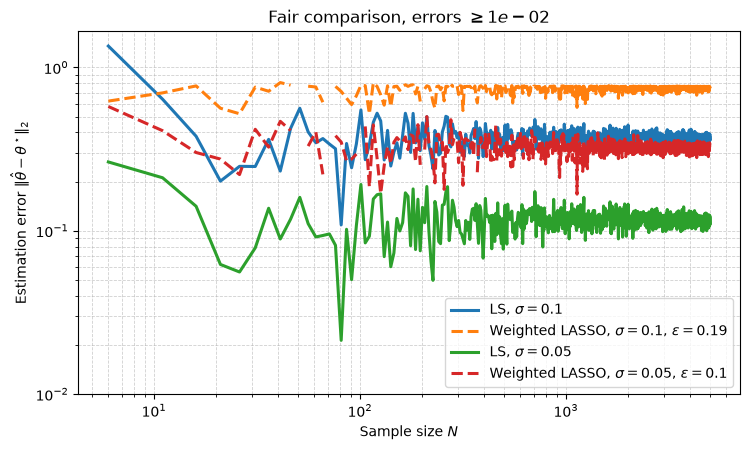

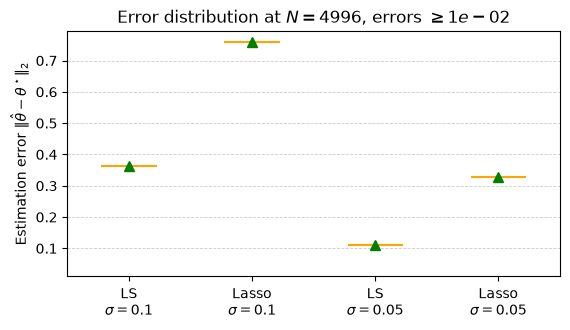


Summary:

Noise std: 0.1
Epsilon:   0.19
Final LS mean error:     0.363982
Final LASSO mean error:  0.760879

Noise std: 0.05
Epsilon:   0.1
Final LS mean error:     0.110016
Final LASSO mean error:  0.328651


In [8]:
# Main
def main():
    all_results = run_all_experiments()

    # Mean-error curves
    fig, ax = plot_all_results(all_results)

    save_figure(
        fig,
        fig_dir=FIG_DIR,
        basename=FIG_BASENAME,
        axis_width=r"\linewidth",
        axis_height=r"0.58\linewidth",
    )

    # Box plot
    fig_box, ax_box = plot_boxplot_results(
        all_results,
        N_box=N_BOX,
    )

    save_figure(
        fig_box,
        fig_dir=FIG_DIR,
        basename=BOXPLOT_BASENAME,
        axis_width=r"0.72\linewidth",
        axis_height=r"0.48\linewidth",
    )

    plt.show()

    print("\nSummary:")

    for result in all_results:
        print(f"\nNoise std: {result['noise_std']}")
        print(f"Epsilon:   {result['epsilon']}")
        print(f"Final LS mean error:     {result['ls_mean'][-1]:.6g}")
        print(f"Final LASSO mean error:  {result['lasso_mean'][-1]:.6g}")

    return all_results

# User choices
PLOT_ERROR_THRESHOLD = 1e-2

N_LAG = 2

NUM_TRIALS = 1
SAMPLE_SIZES = list(range(1, 5001, 5))

# Choose epsilon separately for each noise std here.
NOISE_EXPERIMENTS = [
    {
        "noise_std": 0.1,
        "epsilon": 0.19,
    },
    {
        "noise_std": 0.05,
        "epsilon": 0.1,
    },
]

# Weighted constrained LASSO settings
LAMBDA_L2 = 0.0

# Adaptive weights:
#   w_i = 1 / (|theta_init_i| + WEIGHT_DELTA)^WEIGHT_POWER
WEIGHT_DELTA = 1e-6
WEIGHT_POWER = 1.0

RANDOM_SEED = 50

# Print one progress line every this many sample sizes.
PROGRESS_EVERY = 25

# Box plot selected sample size.
# None means final sample size, here N = 5000.
N_BOX = None

FIG_DIR = Path("Figures")
FIG_BASENAME = "ls_lasso_white_noise_two_stds"
BOXPLOT_BASENAME = "ls_lasso_boxplot_two_stds"

# System
A = np.array(
    [
        [0.7, 0.1],
        [0.2, 0.8],
    ],
    dtype=float,
)

B = np.array(
    [
        [1.0],
        [1.0],
    ],
    dtype=float,
)

C = np.array(
    [
        [1.0, -1.0],
    ],
    dtype=float,
)


if __name__ == "__main__":
    results = main()


## Uniform-noise experiment

### Functions used in this section

| Function | Inputs | Purpose |
|---|---|---|
| `design_observer` | `A, C` | Places the observer poles and returns the observer gain and observer state matrix. |
| `compute_true_theta` | `A_o, B, C, G, n_lag` | Builds the true observer parameter vector from the observer Markov parameters. |
| `make_output_filter` | `A, B, C` | Converts the SISO state-space model to a discrete transfer-function filter. |
| `simulate_output` | `u, noise_mu, filter_numerator, filter_denominator` | Simulates the output efficiently and adds measurement noise. |
| `simulate_state_space` | `A, B, C, u, noise_mu=0.0` | Simulates the full state-space trajectory. |
| `generate_white_noise_input` | `N` | Generates a white Gaussian input sequence. |
| `build_regressor` | `u, y, n_lag` | Constructs the lagged ARX regressor matrix and aligned output vector. |
| `least_squares_statistics` | `Phi, Y` | Helper function used in this experiment. |
| `least_squares_inverse` | `Phi, Y` | Helper function used in this experiment. |
| `adaptive_weights_from_theta` | `theta_init, delta=1e-3, power=1.0` | Helper function used in this experiment. |
| `make_adaptive_lasso_weights` | `Phi, Y, delta=1e-3, power=1.0` | Helper function used in this experiment. |
| `psd_square_root_factor` | `Q` | Helper function used in this experiment. |
| `weighted_lasso_constrained` | `Phi, Y, epsilon, weights=None, lambda_l2=0.0, solver_cache=None, theta_ls=None, Q=None, rss_min=None,` | Solves the constrained weighted-LASSO problem. |
| `run_fair_comparison_one_noise` | `A, B, C, sample_sizes, noise_mu, epsilon, num_trials, n_lag, lambda_l2, weight_delta, weight_power, G=None, A_o=None, theta_true=None, progress_every=25,` | Helper function used in this experiment. |
| `run_all_experiments` | `` | Helper function used in this experiment. |
| `plot_all_results` | `all_results, error_threshold=None,` | Helper function used in this experiment. |
| `plot_boxplot_results` | `all_results, N_box=None, error_threshold=None,` | Helper function used in this experiment. |
| `save_figure` | `fig, fig_dir=None, basename=None, axis_width=r"\linewidth", axis_height=r"0.58\linewidth",` | Helper function used in this experiment. |


In [9]:
from pathlib import Path
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from scipy.signal import lfilter, place_poles, ss2tf
import matplotlib.pyplot as plt
import cvxpy as cp

def design_observer(A, C):
    desired_poles = np.array([1e-8, 2e-15])
    place_obj = place_poles(A.T, C.T, desired_poles)

    G = place_obj.gain_matrix.T
    A_o = A - G @ C

    print("Desired poles:", desired_poles)
    print("Actual placed poles:", place_obj.computed_poles)
    print("Poles of A_o:", np.linalg.eigvals(A_o))

    return G, A_o


def compute_true_theta(A_o, B, C, G, n_lag):
    """Compute Markov parameters without repeated matrix_power calls."""
    theta_u = np.empty(n_lag, dtype=float)
    theta_y = np.empty(n_lag, dtype=float)

    A_power_B = np.asarray(B, dtype=float)
    A_power_G = np.asarray(G, dtype=float)

    for i in range(n_lag):
        theta_u[i] = (C @ A_power_B).item()
        theta_y[i] = (C @ A_power_G).item()
        A_power_B = A_o @ A_power_B
        A_power_G = A_o @ A_power_G

    return np.hstack((theta_u, theta_y))

def make_output_filter(A, B, C):
    """
    Convert the SISO state-space model to a discrete transfer function.

    With x[0] = 0 and D = 0, lfilter produces the same output sequence
    y[k] = C x[k] as the state recursion, up to floating-point roundoff.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)

    if B.shape[1] != 1 or C.shape[0] != 1:
        raise ValueError("The output filter currently requires a SISO system.")

    D = np.zeros((C.shape[0], B.shape[1]), dtype=float)
    numerator, denominator = ss2tf(A, B, C, D)

    return np.asarray(numerator[0], dtype=float), np.asarray(denominator, dtype=float)


def simulate_output(u, noise_mu, filter_numerator, filter_denominator):
    """Output-only simulation used by the Monte Carlo experiment."""
    u = np.asarray(u, dtype=float).reshape(-1)

    y = lfilter(filter_numerator, filter_denominator, u)

    # Draw all N uniform-noise samples in one vectorized call.
    y = y + np.random.uniform(-float(noise_mu), float(noise_mu), size=u.size)

    return y


def simulate_state_space(A, B, C, u, noise_mu=0.0):
    """
    Compatibility version that still returns the full state trajectory.

    The main experiment uses simulate_output because it does not need x.
    """
    u = np.asarray(u, dtype=float).reshape(-1)

    N = u.size
    n = A.shape[0]

    x = np.zeros((N + 1, n), dtype=float)
    B_flat = np.asarray(B, dtype=float).reshape(-1)

    for k in range(N):
        x[k + 1] = A @ x[k] + B_flat * u[k]

    noise = np.random.uniform(-float(noise_mu), float(noise_mu), size=N)
    y = x[:-1] @ np.asarray(C, dtype=float).reshape(-1) + noise

    return x, y


def generate_white_noise_input(N):
    """
    White Gaussian input:
        u_k ~ N(0, 1)
    """
    return np.random.randn(int(N))

def build_regressor(u, y, n_lag):
    """Vectorized replacement for the original row-by-row Python loop."""
    u = np.asarray(u, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if u.size != y.size:
        raise ValueError("u and y must have the same length.")

    N = u.size
    n_lag = int(n_lag)

    if N <= n_lag:
        return (
            np.zeros((0, 2 * n_lag), dtype=float),
            np.zeros((0, 1), dtype=float),
        )

    # For k = n_lag, ..., N-1, use samples [k-n_lag, ..., k-1]
    # and reverse them so the most recent value appears first.
    u_lags = sliding_window_view(u, n_lag)[:-1, ::-1]
    y_lags = sliding_window_view(y, n_lag)[:-1, ::-1]

    Phi = np.ascontiguousarray(np.hstack((u_lags, y_lags)), dtype=float)
    Y = np.ascontiguousarray(y[n_lag:, None], dtype=float)

    return Phi, Y

def least_squares_statistics(Phi, Y):
    """
    Return LS estimate and the small p-by-p statistics needed by LASSO.

    This avoids computing a matrix inverse and avoids doing a second
    pseudoinverse solely for the adaptive weights.
    """
    Phi = np.asarray(Phi, dtype=float)
    y = np.asarray(Y, dtype=float).reshape(-1)

    Q = Phi.T @ Phi
    q = Phi.T @ y

    try:
        theta_ls = np.linalg.solve(Q, q)
    except np.linalg.LinAlgError:
        theta_ls = np.linalg.lstsq(Phi, y, rcond=None)[0]

    residual = Phi @ theta_ls - y
    rss_min = float(residual @ residual)

    return theta_ls, Q, rss_min


def least_squares_inverse(Phi, Y):
    """Drop-in replacement for the original explicit-inverse function."""
    theta_hat, _, _ = least_squares_statistics(Phi, Y)
    return theta_hat

def adaptive_weights_from_theta(theta_init, delta=1e-3, power=1.0):
    theta_init = np.asarray(theta_init, dtype=float).reshape(-1)

    weights = 1.0 / (
        (np.abs(theta_init) + float(delta)) ** float(power)
    )
    weights /= np.mean(weights)

    return weights


def make_adaptive_lasso_weights(Phi, Y, delta=1e-3, power=1.0):
    """Compatibility wrapper using the same LS initializer."""
    theta_init, _, _ = least_squares_statistics(Phi, Y)
    return adaptive_weights_from_theta(theta_init, delta=delta, power=power)

def psd_square_root_factor(Q):
    """
    Return R such that R.T @ R == Q, up to floating-point roundoff.
    """
    Q = np.asarray(Q, dtype=float)
    Q = 0.5 * (Q + Q.T)

    try:
        # Q = L L.T, so R = L.T gives R.T R = Q.
        return np.linalg.cholesky(Q).T
    except np.linalg.LinAlgError:
        eigenvalues, eigenvectors = np.linalg.eigh(Q)
        scale = max(1.0, float(np.max(np.abs(eigenvalues))))
        tolerance = 1e-12 * scale

        if np.min(eigenvalues) < -100.0 * tolerance:
            raise np.linalg.LinAlgError("Phi.T @ Phi is not positive semidefinite.")

        eigenvalues = np.clip(eigenvalues, 0.0, None)
        return np.sqrt(eigenvalues)[:, None] * eigenvectors.T


class FastWeightedLassoSolver:
    """
    Reusable p-dimensional solver for

        minimize    sum_i w_i |theta_i| + lambda_l2/2 ||theta||_2^2
        subject to  ||Phi theta - Y||_2 <= epsilon sqrt(T).

    The residual constraint is reduced exactly using

        ||Phi theta - Y||_2^2
        = RSS_min + (theta-theta_ls).T (Phi.T Phi) (theta-theta_ls).

    Therefore CVXPY sees only a p-dimensional SOC, not a T-dimensional one.
    """

    def __init__(self, p, lambda_l2=0.0):
        self.p = int(p)
        self.lambda_l2 = float(lambda_l2)

        self.theta = cp.Variable(self.p)
        self.factor = cp.Parameter((self.p, self.p))
        self.centered_target = cp.Parameter(self.p)
        self.radius = cp.Parameter(nonneg=True)
        self.weights = cp.Parameter(self.p, nonneg=True)

        weighted_l1 = cp.norm1(cp.multiply(self.weights, self.theta))

        if self.lambda_l2 > 0.0:
            objective = cp.Minimize(
                weighted_l1
                + 0.5 * self.lambda_l2 * cp.sum_squares(self.theta)
            )
        else:
            objective = cp.Minimize(weighted_l1)

        constraints = [
            cp.norm(
                self.factor @ self.theta - self.centered_target,
                2,
            )
            <= self.radius
        ]

        self.problem = cp.Problem(objective, constraints)
        self.installed_solvers = set(cp.installed_solvers())

    def solve(self, Q, theta_ls, rss_min, T, epsilon, weights):
        Q = np.asarray(Q, dtype=float)
        theta_ls = np.asarray(theta_ls, dtype=float).reshape(-1)
        weights = np.asarray(weights, dtype=float).reshape(-1)

        if theta_ls.size != self.p:
            raise ValueError(f"theta_ls must have length {self.p}.")
        if weights.size != self.p:
            raise ValueError(f"weights must have length {self.p}.")
        if np.any(weights < 0.0) or not np.all(np.isfinite(weights)):
            raise ValueError("weights must be finite and nonnegative.")

        allowed_rss = float(epsilon) ** 2 * int(T)
        radius_squared = allowed_rss - float(rss_min)

        feasibility_tolerance = 1e-10 * max(
            1.0,
            abs(allowed_rss),
            abs(float(rss_min)),
        )

        if radius_squared < -feasibility_tolerance:
            raise ValueError(
                "Constrained weighted LASSO is infeasible: "
                f"minimum RSS={rss_min:.6g} exceeds "
                f"epsilon^2*T={allowed_rss:.6g}."
            )

        radius_squared = max(radius_squared, 0.0)
        factor = psd_square_root_factor(Q)

        self.factor.value = factor
        self.centered_target.value = factor @ theta_ls
        self.radius.value = np.sqrt(radius_squared)
        self.weights.value = weights

        solver_attempts = []

        if "CLARABEL" in self.installed_solvers:
            solver_attempts.append(
                (
                    "CLARABEL",
                    dict(
                        warm_start=True,
                        verbose=False,
                        max_iter=1000,
                        tol_gap_abs=1e-8,
                        tol_gap_rel=1e-8,
                        tol_feas=1e-8,
                    ),
                )
            )

        if "ECOS" in self.installed_solvers:
            solver_attempts.append(
                (
                    "ECOS",
                    dict(
                        warm_start=True,
                        verbose=False,
                        max_iters=3000,
                        reltol=1e-7,
                        abstol=1e-7,
                        feastol=1e-7,
                    ),
                )
            )

        if "SCS" in self.installed_solvers:
            solver_attempts.append(
                (
                    "SCS",
                    dict(
                        warm_start=True,
                        verbose=False,
                        eps=1e-5,
                        max_iters=10000,
                        alpha=1.8,
                        acceleration_lookback=20,
                    ),
                )
            )

        if not solver_attempts:
            solver_attempts.append((None, dict(warm_start=True, verbose=False)))

        last_exception = None

        for solver, kwargs in solver_attempts:
            try:
                if solver is None:
                    self.problem.solve(**kwargs)
                else:
                    self.problem.solve(solver=solver, **kwargs)

                if (
                    self.theta.value is not None
                    and self.problem.status in {
                        cp.OPTIMAL,
                        cp.OPTIMAL_INACCURATE,
                    }
                    and np.all(np.isfinite(self.theta.value))
                ):
                    return np.asarray(self.theta.value, dtype=float).copy()

            except Exception as exc:
                last_exception = exc

        if last_exception is not None:
            raise ValueError(
                "Constrained weighted LASSO optimization failed."
            ) from last_exception

        raise ValueError(
            "Constrained weighted LASSO optimization failed with status "
            f"{self.problem.status!r}."
        )


def weighted_lasso_constrained(
    Phi,
    Y,
    epsilon,
    weights=None,
    lambda_l2=0.0,
    solver_cache=None,
    theta_ls=None,
    Q=None,
    rss_min=None,
):
    """
    Drop-in function with optional cached statistics and reusable solver.
    """
    Phi = np.asarray(Phi, dtype=float)
    y = np.asarray(Y, dtype=float).reshape(-1)

    T, p = Phi.shape

    if weights is None:
        weights = np.ones(p, dtype=float)

    if theta_ls is None or Q is None or rss_min is None:
        theta_ls, Q, rss_min = least_squares_statistics(Phi, y)

    if solver_cache is None:
        solver_cache = FastWeightedLassoSolver(p, lambda_l2=lambda_l2)

    return solver_cache.solve(
        Q=Q,
        theta_ls=theta_ls,
        rss_min=rss_min,
        T=T,
        epsilon=epsilon,
        weights=weights,
    )

def run_fair_comparison_one_noise(
    A,
    B,
    C,
    sample_sizes,
    noise_mu,
    epsilon,
    num_trials,
    n_lag,
    lambda_l2,
    weight_delta,
    weight_power,
    G=None,
    A_o=None,
    theta_true=None,
    progress_every=25,
):
    if G is None or A_o is None:
        G, A_o = design_observer(A, C)

    if theta_true is None:
        theta_true = compute_true_theta(A_o, B, C, G, n_lag)

    print(f"\nUniform noise mu = {noise_mu}, epsilon = {epsilon}")
    print("Common theta_true:")
    print(theta_true)

    sample_sizes = list(sample_sizes)

    ls_errors = np.full((len(sample_sizes), num_trials), np.nan)
    lasso_errors = np.full((len(sample_sizes), num_trials), np.nan)

    filter_numerator, filter_denominator = make_output_filter(A, B, C)
    lasso_solver = FastWeightedLassoSolver(
        p=2 * n_lag,
        lambda_l2=lambda_l2,
    )

    progress_every = max(1, int(progress_every))

    for i, N in enumerate(sample_sizes):
        if N <= n_lag:
            continue

        for trial in range(num_trials):
            # SAME WHITE-NOISE DATA FOR BOTH METHODS
            u = generate_white_noise_input(N)
            y = simulate_output(
                u=u,
                noise_mu=noise_mu,
                filter_numerator=filter_numerator,
                filter_denominator=filter_denominator,
            )

            Phi, Y = build_regressor(u, y, n_lag)

            if Phi.shape[0] == 0:
                continue

            # LS + shared statistics for adaptive LASSO weights
            try:
                theta_ls, Q, rss_min = least_squares_statistics(Phi, Y)
                ls_errors[i, trial] = np.linalg.norm(theta_ls - theta_true)

            except np.linalg.LinAlgError:
                print(f"LS solve failed N={N}, trial={trial}")
                continue

            # Weighted constrained LASSO
            try:
                weights = adaptive_weights_from_theta(
                    theta_ls,
                    delta=weight_delta,
                    power=weight_power,
                )

                theta_lasso = lasso_solver.solve(
                    Q=Q,
                    theta_ls=theta_ls,
                    rss_min=rss_min,
                    T=Phi.shape[0],
                    epsilon=epsilon,
                    weights=weights,
                )

                lasso_errors[i, trial] = np.linalg.norm(
                    theta_lasso - theta_true
                )

            except Exception as exc:
                print(
                    f"Weighted LASSO failed N={N}, "
                    f"trial={trial}: {exc}"
                )
                lasso_errors[i, trial] = np.nan

        if (
            (i + 1) % progress_every == 0
            or i == 0
            or i + 1 == len(sample_sizes)
        ):
            print(
                f"mu={noise_mu}, epsilon={epsilon}: "
                f"finished N={N} ({i + 1}/{len(sample_sizes)})"
            )

    return {
        "noise_mu": noise_mu,
        "epsilon": epsilon,
        "theta_true": theta_true,
        "sample_sizes": np.asarray(sample_sizes),
        "ls_errors": ls_errors,
        "lasso_errors": lasso_errors,
    }

def run_all_experiments():
    min_N = N_LAG + 1

    sample_sizes = sorted(
        {
            int(N)
            for N in SAMPLE_SIZES
            if int(N) >= min_N
        }
    )

    # Observer design and true theta do not depend on the noise level.
    G, A_o = design_observer(A, C)
    theta_true = compute_true_theta(A_o, B, C, G, N_LAG)

    all_results = []

    for config in NOISE_EXPERIMENTS:
        noise_mu = config["mu"]
        epsilon = config["epsilon"]

        # Preserve the original behavior: each noise experiment starts from
        # the same RNG seed.
        np.random.seed(RANDOM_SEED)

        result = run_fair_comparison_one_noise(
            A=A,
            B=B,
            C=C,
            sample_sizes=sample_sizes,
            noise_mu=noise_mu,
            epsilon=epsilon,
            num_trials=NUM_TRIALS,
            n_lag=N_LAG,
            lambda_l2=LAMBDA_L2,
            weight_delta=WEIGHT_DELTA,
            weight_power=WEIGHT_POWER,
            G=G,
            A_o=A_o,
            theta_true=theta_true,
            progress_every=PROGRESS_EVERY,
        )

        all_results.append(result)

    return all_results


# Plot all four mean curves
# Errors below PLOT_ERROR_THRESHOLD are omitted from the plot.
# The underlying simulation arrays and summary statistics are unchanged.
def plot_all_results(
    all_results,
    error_threshold=None,
):
    if error_threshold is None:
        error_threshold = PLOT_ERROR_THRESHOLD

    error_threshold = float(error_threshold)

    if error_threshold < 0.0:
        raise ValueError("error_threshold must be nonnegative.")

    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    plotted_any_curve = False

    for result in all_results:
        sample_sizes = np.asarray(result["sample_sizes"], dtype=float)
        noise_mu = result["noise_mu"]
        epsilon = result["epsilon"]

        ls_errors = np.asarray(result["ls_errors"], dtype=float)
        lasso_errors = np.asarray(result["lasso_errors"], dtype=float)

        # Compute statistics from all finite simulation results. Filtering is
        # applied only to the values sent to Matplotlib.
        ls_mean = np.nanmean(ls_errors, axis=1)
        ls_std = np.nanstd(ls_errors, axis=1)

        lasso_mean = np.nanmean(lasso_errors, axis=1)
        lasso_std = np.nanstd(lasso_errors, axis=1)

        result["ls_mean"] = ls_mean
        result["ls_std"] = ls_std
        result["lasso_mean"] = lasso_mean
        result["lasso_std"] = lasso_std

        # Least squares
        ls_valid = np.isfinite(ls_mean) & (ls_mean >= error_threshold)

        if np.any(ls_valid):
            plotted_any_curve = True

            ls_mean_plot = np.where(ls_valid, ls_mean, np.nan)
            ls_lower = np.where(
                ls_valid,
                np.maximum(ls_mean - 1.645 * ls_std, error_threshold),
                np.nan,
            )
            ls_upper = np.where(
                ls_valid,
                np.maximum(ls_mean + 1.645 * ls_std, error_threshold),
                np.nan,
            )

            ax.plot(
                sample_sizes,
                ls_mean_plot,
                linewidth=2.2,
                label=rf"LS, $\mu={noise_mu}$",
            )

            ax.fill_between(
                sample_sizes,
                ls_lower,
                ls_upper,
                where=ls_valid,
                interpolate=False,
                alpha=0.10,
            )

        # Weighted constrained LASSO
        lasso_valid = (
            np.isfinite(lasso_mean)
            & (lasso_mean >= error_threshold)
        )

        if np.any(lasso_valid):
            plotted_any_curve = True

            lasso_mean_plot = np.where(
                lasso_valid,
                lasso_mean,
                np.nan,
            )
            lasso_lower = np.where(
                lasso_valid,
                np.maximum(lasso_mean - lasso_std, error_threshold),
                np.nan,
            )
            lasso_upper = np.where(
                lasso_valid,
                np.maximum(lasso_mean + lasso_std, error_threshold),
                np.nan,
            )

            ax.plot(
                sample_sizes,
                lasso_mean_plot,
                linewidth=2.2,
                linestyle="--",
                label=(
                    rf"Weighted LASSO, $\mu={noise_mu}$, "
                    rf"$\epsilon={epsilon}$"
                ),
            )

            ax.fill_between(
                sample_sizes,
                lasso_lower,
                lasso_upper,
                where=lasso_valid,
                interpolate=False,
                alpha=0.10,
            )

    ax.set_xlabel(r"Sample size $N$")
    ax.set_ylabel(r"Estimation error $\|\hat{\theta}-\theta^\star\|_2$")
    ax.set_title(
        rf"Fair comparison with uniform output noise, errors $\geq {error_threshold:.0e}$"
    )

    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=10)

    # Ensure that no part of the displayed y-axis falls below the threshold.
    if plotted_any_curve:
        _, current_top = ax.get_ylim()
        ax.set_ylim(bottom=error_threshold, top=current_top)
    else:
        ax.set_ylim(error_threshold, 10.0 * error_threshold)

    ax.grid(
        True,
        which="both",
        linestyle="--",
        linewidth=0.6,
        alpha=0.6,
    )

    if plotted_any_curve:
        ax.legend(frameon=True)

    fig.tight_layout()

    return fig, ax


# Box plot at selected sample size
# Individual errors below PLOT_ERROR_THRESHOLD are omitted.
def plot_boxplot_results(
    all_results,
    N_box=None,
    error_threshold=None,
):
    if error_threshold is None:
        error_threshold = PLOT_ERROR_THRESHOLD

    error_threshold = float(error_threshold)

    if error_threshold < 0.0:
        raise ValueError("error_threshold must be nonnegative.")

    box_data = []
    box_labels = []
    used_N_values = []

    for result in all_results:
        sample_sizes = np.asarray(result["sample_sizes"])
        noise_mu = result["noise_mu"]

        if N_box is None:
            idx = -1
        else:
            idx = int(np.argmin(np.abs(sample_sizes - N_box)))

        used_N = int(sample_sizes[idx])
        used_N_values.append(used_N)

        ls_vals = np.asarray(result["ls_errors"][idx, :], dtype=float)
        lasso_vals = np.asarray(
            result["lasso_errors"][idx, :],
            dtype=float,
        )

        ls_vals = ls_vals[
            np.isfinite(ls_vals)
            & (ls_vals >= error_threshold)
        ]
        lasso_vals = lasso_vals[
            np.isfinite(lasso_vals)
            & (lasso_vals >= error_threshold)
        ]

        # Keep a placeholder when every value in a group is filtered out.
        if ls_vals.size == 0:
            ls_vals = np.array([np.nan])

        if lasso_vals.size == 0:
            lasso_vals = np.array([np.nan])

        box_data.append(ls_vals)
        box_labels.append(rf"LS" + "\n" + rf"$\mu={noise_mu}$")

        box_data.append(lasso_vals)
        box_labels.append(rf"Lasso" + "\n" + rf"$\mu={noise_mu}$")

    fig, ax = plt.subplots(figsize=(5.8, 3.4))

    import inspect

    label_parameter = (
        "tick_labels"
        if "tick_labels" in inspect.signature(ax.boxplot).parameters
        else "labels"
    )

    bp = ax.boxplot(
        box_data,
        **{label_parameter: box_labels},
        patch_artist=True,
        showmeans=True,
        meanprops=dict(
            marker="^",
            markerfacecolor="green",
            markeredgecolor="green",
            markersize=7,
        ),
        medianprops=dict(
            linewidth=1.5,
            color="orange",
        ),
        boxprops=dict(
            linewidth=1.1,
            color="black",
        ),
        whiskerprops=dict(
            linewidth=1.1,
            color="black",
        ),
        capprops=dict(
            linewidth=1.1,
            color="black",
        ),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="none",
            markeredgecolor="black",
        ),
    )

    box_colors = ["lightblue", "wheat", "lightblue", "wheat"]

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.90)

    used_N_unique = sorted(set(used_N_values))

    if len(used_N_unique) == 1:
        title_N = used_N_unique[0]
    else:
        title_N = used_N_unique

    ax.set_ylabel(r"Estimation error $\|\hat{\theta}-\theta^\star\|_2$")
    ax.set_title(
        rf"Uniform-noise error distribution at $N={title_N}$, "
        rf"errors $\geq {error_threshold:.0e}$"
    )

    # Keep the boxplot y-axis linear.
    ax.set_ylim(bottom=error_threshold)

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.65,
    )
    ax.set_axisbelow(True)

    fig.tight_layout()

    return fig, ax

def save_figure(
    fig,
    fig_dir=None,
    basename=None,
    axis_width=r"\linewidth",
    axis_height=r"0.58\linewidth",
):
    if fig_dir is None:
        fig_dir = FIG_DIR

    if basename is None:
        basename = FIG_BASENAME

    fig_dir = Path(fig_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = fig_dir / f"{basename}.pdf"
    png_path = fig_dir / f"{basename}.png"
    tex_path = fig_dir / f"{basename}.tex"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"Saved PDF: {pdf_path}")
    print(f"Saved PNG: {png_path}")

    import tikzplotlib

    # Patch Line2D dash attributes expected by tikzplotlib
    for ax in fig.axes:
        for line in ax.get_lines():
            if not hasattr(line, "_us_dashSeq"):
                dash_pattern = getattr(line, "_unscaled_dash_pattern", None)

                if dash_pattern is None:
                    dash_pattern = getattr(line, "_dash_pattern", None)

                if dash_pattern is None:
                    dash_offset = 0
                    dash_seq = ()
                else:
                    dash_offset, dash_seq = dash_pattern
                    if dash_seq is None:
                        dash_seq = ()

                line._us_dashSeq = dash_seq
                line._us_dashOffset = dash_offset

            if not hasattr(line, "_us_dashOffset"):
                line._us_dashOffset = 0

        legend = ax.get_legend()
        if legend is not None:
            if hasattr(legend, "_ncols") and not hasattr(legend, "_ncol"):
                legend._ncol = legend._ncols

    # Patch webcolors issue if present
    try:
        import webcolors

        if not hasattr(webcolors, "CSS3_HEX_TO_NAMES"):
            try:
                webcolors.CSS3_HEX_TO_NAMES = {
                    webcolors.name_to_hex(name): name
                    for name in webcolors.names("css3")
                }
            except Exception:
                webcolors.CSS3_HEX_TO_NAMES = {
                    "#000000": "black",
                    "#ffffff": "white",
                    "#ff0000": "red",
                    "#00ff00": "lime",
                    "#0000ff": "blue",
                    "#ffff00": "yellow",
                    "#00ffff": "cyan",
                    "#ff00ff": "magenta",
                    "#808080": "gray",
                    "#008000": "green",
                    "#800000": "maroon",
                    "#000080": "navy",
                    "#800080": "purple",
                    "#008080": "teal",
                    "#c0c0c0": "silver",
                }
    except Exception:
        pass

    tikzplotlib.save(
        str(tex_path),
        figure=fig,
        axis_width=axis_width,
        axis_height=axis_height,
        strict=False,
        standalone=False,
    )

    print(f"Saved TikZ/PGFPlots file: {tex_path}")


### Main experiment

This block sets the experiment parameters, defines the system, runs the Monte Carlo study, and generates/exports the figure outputs.


(CVXPY) Sep 11 11:36:17 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('libhighs.so.1: cannot open shared object file: No such file or directory')


Desired poles: [1.e-08 2.e-15]
Actual placed poles: [1.22625725e-08+0.j 4.60920356e-08+0.j]
Poles of A_o: [ 5.83546086e-08+0.j -3.25617861e-16+0.j]

Uniform noise mu = 0.1, epsilon = 0.11
Common theta_true:
[ 0.         -0.2         1.49999994 -0.53999991]
mu=0.1, epsilon=0.11: finished N=6 (1/999)
Weighted LASSO failed N=11, trial=8: Constrained weighted LASSO is infeasible: minimum RSS=0.112555 exceeds epsilon^2*T=0.1089.
Weighted LASSO failed N=11, trial=9: Constrained weighted LASSO is infeasible: minimum RSS=0.111213 exceeds epsilon^2*T=0.1089.
Weighted LASSO failed N=11, trial=19: Constrained weighted LASSO is infeasible: minimum RSS=0.116925 exceeds epsilon^2*T=0.1089.
Weighted LASSO failed N=16, trial=1: Constrained weighted LASSO is infeasible: minimum RSS=0.176288 exceeds epsilon^2*T=0.1694.
Weighted LASSO failed N=16, trial=4: Constrained weighted LASSO is infeasible: minimum RSS=0.192046 exceeds epsilon^2*T=0.1694.
Weighted LASSO failed N=16, trial=8: Constrained weighted L

(CVXPY) Sep 11 11:36:44 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('libhighs.so.1: cannot open shared object file: No such file or directory')


mu=0.1, epsilon=0.11: finished N=4996 (999/999)

Uniform noise mu = 0.05, epsilon = 0.055
Common theta_true:
[ 0.         -0.2         1.49999994 -0.53999991]
mu=0.05, epsilon=0.055: finished N=6 (1/999)
Weighted LASSO failed N=11, trial=8: Constrained weighted LASSO is infeasible: minimum RSS=0.0342211 exceeds epsilon^2*T=0.027225.
Weighted LASSO failed N=11, trial=9: Constrained weighted LASSO is infeasible: minimum RSS=0.0293235 exceeds epsilon^2*T=0.027225.
Weighted LASSO failed N=11, trial=12: Constrained weighted LASSO is infeasible: minimum RSS=0.0280446 exceeds epsilon^2*T=0.027225.
Weighted LASSO failed N=16, trial=1: Constrained weighted LASSO is infeasible: minimum RSS=0.0512294 exceeds epsilon^2*T=0.04235.
Weighted LASSO failed N=16, trial=4: Constrained weighted LASSO is infeasible: minimum RSS=0.0635656 exceeds epsilon^2*T=0.04235.
Weighted LASSO failed N=16, trial=8: Constrained weighted LASSO is infeasible: minimum RSS=0.0496637 exceeds epsilon^2*T=0.04235.
Weighted LAS

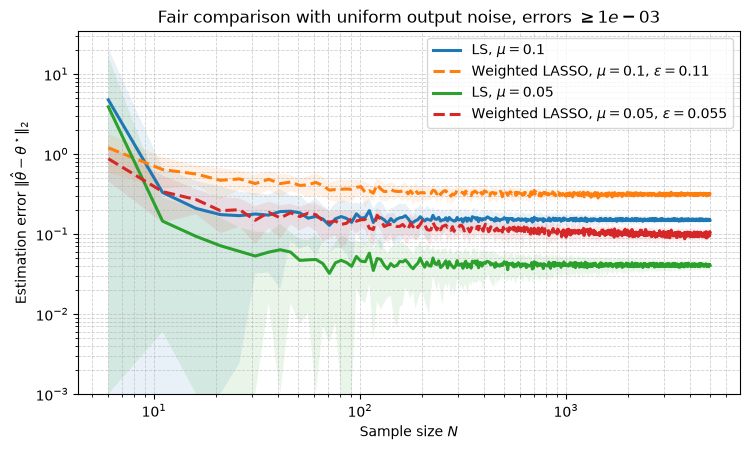

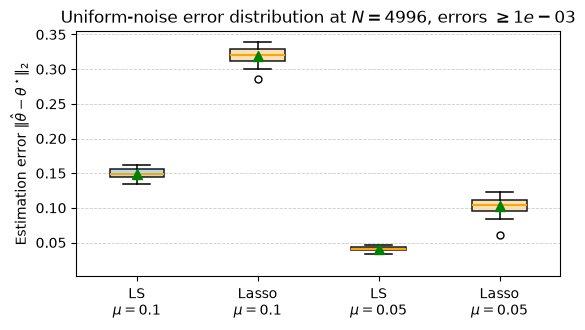


Summary:

Uniform noise mu: 0.1
Epsilon:   0.11
Final LS mean error:     0.149238
Final LASSO mean error:  0.318958

Uniform noise mu: 0.05
Epsilon:   0.055
Final LS mean error:     0.0406554
Final LASSO mean error:  0.102153


In [10]:
# Main
def main():
    all_results = run_all_experiments()

    # Mean-error curves
    fig, ax = plot_all_results(all_results)

    save_figure(
        fig,
        fig_dir=FIG_DIR,
        basename=FIG_BASENAME,
        axis_width=r"\linewidth",
        axis_height=r"0.58\linewidth",
    )

    # Box plot
    fig_box, ax_box = plot_boxplot_results(
        all_results,
        N_box=N_BOX,
    )

    save_figure(
        fig_box,
        fig_dir=FIG_DIR,
        basename=BOXPLOT_BASENAME,
        axis_width=r"0.72\linewidth",
        axis_height=r"0.48\linewidth",
    )

    plt.show()

    print("\nSummary:")

    for result in all_results:
        print(f"\nUniform noise mu: {result['noise_mu']}")
        print(f"Epsilon:   {result['epsilon']}")
        print(f"Final LS mean error:     {result['ls_mean'][-1]:.6g}")
        print(f"Final LASSO mean error:  {result['lasso_mean'][-1]:.6g}")

    return all_results

# User choices
PLOT_ERROR_THRESHOLD = 1e-3

N_LAG = 2

NUM_TRIALS = 20
SAMPLE_SIZES = list(range(1, 5001, 5))

# Uniform output noise:
#   e(k) ~ U[-mu, mu]
#
# Choose epsilon separately for each mu here.
NOISE_EXPERIMENTS = [
    {
        "mu": 0.1,
        "epsilon": 0.11,
    },
    {
        "mu": 0.05,
        "epsilon": 0.055,
    },
]

# Weighted constrained LASSO settings
LAMBDA_L2 = 0.0

# Adaptive weights:
#   w_i = 1 / (|theta_init_i| + WEIGHT_DELTA)^WEIGHT_POWER
WEIGHT_DELTA = 1e-6
WEIGHT_POWER = 1.0

RANDOM_SEED = 50

# Print one progress line every this many sample sizes.
PROGRESS_EVERY = 25

# Box plot selected sample size.
# None means final sample size, here N = 500.
N_BOX = None

FIG_DIR = Path("Figures")
FIG_BASENAME = "ls_lasso_uniform_noise_two_mus_fast"
BOXPLOT_BASENAME = "ls_lasso_uniform_boxplot_two_mus_fast"

# System
A = np.array(
    [
        [0.7, 0.1],
        [0.2, 0.8],
    ],
    dtype=float,
)

B = np.array(
    [
        [1.0],
        [1.0],
    ],
    dtype=float,
)

C = np.array(
    [
        [1.0, -1.0],
    ],
    dtype=float,
)


if __name__ == "__main__":
    results_uniform_fast = main()
